In [4]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import plotly.express as px

In [5]:
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format',  '{:.4f}'.format)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
# pd.set_option('display.max_colwidth', 500)
pd.options.mode.chained_assignment = None

# Introduction: Comprehensive Analysis of Kokam


**Objective:**

This Jupyter Notebook aims to conduct a comprehensive analysis of KOKAM SLPB 52495 Pouch Cell through a series of charge-discharge cycles. The primary goals are to:

1. **Understand Battery Behavior:** Investigate the charging and discharging characteristics of both battery types, including voltage, current, and capacity.

**Experimental Setup:**

The experiment involves subjecting Kokam batteries to multiple charge-discharge cycles, simulating real-world usage conditions. Data on voltage, current, and temperature will be collected throughout these cycles.

**Data Analysis and Visualization:**

Various data visualization techniques will be employed to analyze the battery's performance, including:

- **Charge-Discharge Curves:** Visualizing the voltage and current profiles during charging and discharging.
- **Capacity Analysis:** Tracking changes in battery capacity over time.
- **Power Consumption:** Analyzing the relationship between power consumption and voltage.
- **Correlation Analysis:** Identifying correlations between different variables using a heatmap.
- **Hysteresis Loop:** Illustrating the difference between charge and discharge capacities.

**Charge Factor Calculation:**

The "charge factor" will be calculated to quantify variations in charging and discharging capacities, providing a measure of the battery's efficiency.

**Key Insights:**

The analysis will provide valuable insights into the performance of Kokam batteries, including:

- Identification of any inefficiencies or performance degradation.
- Understanding the factors influencing battery capacity.


# KOKAM SLPB 52495 Pouch Cell

## General Specifications

| Item | Specification | Remarks |
|---|---|---|
| 3.1 Nominal Capacity | 3.3 Ah | 0.5C/0.5C, 2.7V cut-off |
| 3.2 Nominal Voltage | 3.7 V | 2.7V - 4.2V |
| 3.3 Charging Method | CC/CV | Constant Current / Constant Voltage |
| 3.4 Charging Current (Std.) | 1.65 A | 0.5C, 0 - 45°C |
| 3.5 Charging Current (Max.) | 6.6 A | 2C |
| 3.6 Charging End Condition | 165 mA | ±0.03V |
| 3.7 Charging Voltage | 4.2 V | |
| 3.8 Charging Time (Std.) | 5 hours | CC + CV mode |
| 3.9 Discharging Current (Std.) | 1.65 A | 0.5C, 20 - 60°C |
| 3.10 Discharging Current (Max.) | 6.6 A | 2C |
| 3.11 Pulse Discharging (Max.) | 9.9 A | 3C, Less than 10 sec. |
| 3.12 Discharge Cut-off Voltage | 3 V | |
| 3.13 Cycle (Min. Capacity) | 2.64 Ah | 1C/1C, 1000cycle@25°C |
| 3.14 Cell Weight | 64.0 g | For bare one cell |
| 3.15 Storage Temperature Range | -20 - 60°C | For up to one month |
| | -20 - 40°C | For up to three months |
| | -20 - 25°C | For up to one year |

### Data Loading and Exploration

In [6]:
# Importing the datafile
df = pd.read_excel('/content/kokum_data.xlsx')
df.head()

,Time[h],DataSet,DateTime,t-Step[h],t-Set[h],Line,Command,U[V],I[A],Ah[Ah],Ah-Cyc-Charge-0,Ah-Cyc-Discharge-0,Ah-Step,Ah-Set,Wh[Wh],Cyc-Count,State,Power[W],Charge
0,0.0167,1,17.01.2024 09:25:34,0.0000,0.0167,3,Charge,3.7874,-0.0011,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,1,3,-0.0041,NaN
1,0.0167,2,17.01.2024 09:25:34,0.0000,0.0167,3,Charge,3.8540,1.6980,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0,6.5441,0.0000
2,0.0168,3,17.01.2024 09:25:34,0.0000,0.0168,3,Charge,3.8740,1.6484,0.0000,0.0000,0.0000,0.0000,0.0000,0.0001,1,1,6.3858,0.0000
3,0.0251,4,17.01.2024 09:26:04,0.0083,0.0251,3,Charge,3.8912,1.6500,0.0137,0.0137,0.0000,0.0137,0.0137,0.0534,1,1,6.4205,0.0137
4,0.0334,5,17.01.2024 09:26:34,0.0167,0.0334,3,Charge,3.8984,1.6500,0.0275,0.0275,0.0000,0.0275,0.0275,0.1070,1,1,6.4324,0.0137


In [7]:
df.isna().sum()

,0
Time[h],0
DataSet,0
DateTime,0
t-Step[h],0
t-Set[h],0
Line,0
Command,0
U[V],0
I[A],0
Ah[Ah],0


In [8]:
df.fillna(method='bfill', inplace=True)

In [9]:
df = df.drop('DateTime', axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1247 entries, 0 to 1246
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time[h]             1247 non-null   float64
 1   DataSet             1247 non-null   int64  
 2   t-Step[h]           1247 non-null   float64
 3   t-Set[h]            1247 non-null   float64
 4   Line                1247 non-null   int64  
 5   Command             1247 non-null   object 
 6   U[V]                1247 non-null   float64
 7   I[A]                1247 non-null   float64
 8   Ah[Ah]              1247 non-null   float64
 9   Ah-Cyc-Charge-0     1247 non-null   float64
 10  Ah-Cyc-Discharge-0  1247 non-null   float64
 11  Ah-Step             1247 non-null   float64
 12  Ah-Set              1247 non-null   float64
 13  Wh[Wh]              1247 non-null   float64
 14  Cyc-Count           1247 non-null   int64  
 15  State               1247 non-null   int64  
 16  Power[

## VISUALISAZTION

In [11]:
import plotly.graph_objects as go

# Create figure with secondary y-axis
fig = go.Figure()

# Add traces for Voltage and Current with improved styling
fig.add_trace(
    go.Scatter(
        x=df['Time[h]'],
        y=df['U[V]'],
        name="Voltage",
        line=dict(color='#1f77b4', width=2),  # Blue color with thicker line
        mode='lines+markers',  # Add markers for better visibility
        marker=dict(size=4)
    )
)
fig.add_trace(
    go.Scatter(
        x=df['Time[h]'],
        y=df['I[A]'],
        name="Current",
        line=dict(color='#ff7f0e', width=2),  # Orange color with thicker line
        mode='lines+markers',  # Add markers for better visibility
        marker=dict(size=4),
        yaxis="y2"
    )
)

# Update layout for better visualization
fig.update_layout(
    title='Voltage and Current Over Time',
    xaxis=dict(
        title='Time (hours)',
        gridcolor='rgba(200, 200, 200, 0.5)',  # Light grey grid lines
        tickmode='linear',  # Ensure all time ticks are shown
    ),
    yaxis=dict(
        title="Voltage (V)",
        titlefont=dict(color='#1f77b4'),
        tickfont=dict(color='#1f77b4'),
        gridcolor='rgba(200, 200, 200, 0.5)',  # Light grey grid lines
    ),
    yaxis2=dict(
        title="Current (A)",
        titlefont=dict(color='#ff7f0e'),
        tickfont=dict(color='#ff7f0e'),
        anchor="x",  # Aligns with the main x-axis
        overlaying="y",
        side="right",
        position=0.95,  # Slightly adjust position to the right
        gridcolor='rgba(200, 200, 200, 0.5)',  # Light grey grid lines
    ),
    legend=dict(
        x=0.01, y=0.99,  # Position the legend in the top-left corner
        bordercolor="Black",
        borderwidth=1
    ),
    hovermode='x unified',  # Show a unified tooltip for both lines
    plot_bgcolor='rgba(240, 240, 240, 0.9)'  # Light grey background
)

fig.show()


In [12]:
import plotly.express as px

# Create the line plot with improved styling and additional features
fig = px.line(
    df,
    x='Time[h]',
    y=['Ah-Cyc-Charge-0', 'Ah-Cyc-Discharge-0'],
    title='Ah Cyclic Charge and Discharge Over Time',
    labels={
        'value': 'Charge/Discharge (Ah)',
        'variable': 'Process',
        'Time[h]': 'Time (hours)'
    },
    color_discrete_sequence=["green", "red"]  # Green for charge, red for discharge
)

# Update layout for better visualization
fig.update_layout(
    title=dict(
        text='Ah Cyclic Charge and Discharge Over Time',
        x=0.5,  # Center the title
        xanchor='center'
    ),
    xaxis=dict(
        title='Time (hours)',
        gridcolor='rgba(200, 200, 200, 0.5)',  # Light grey grid lines
        tickmode='linear',  # Ensure all time ticks are shown
        showline=True,  # Show the axis line
        linewidth=2,  # Make axis line thicker
        linecolor='black'  # Set axis line color to black
    ),
    yaxis=dict(
        title='Charge/Discharge (Ah)',
        gridcolor='rgba(200, 200, 200, 0.5)',  # Light grey grid lines
        showline=True,  # Show the axis line
        linewidth=2,  # Make axis line thicker
        linecolor='black'  # Set axis line color to black
    ),
    legend=dict(
        title='Legend',  # Customize legend title
        x=0.01, y=0.99,  # Position legend in the top-left corner
        bordercolor="Black",
        borderwidth=1
    ),
    plot_bgcolor='rgba(240, 240, 240, 0.9)',  # Light grey background for better contrast
    hovermode='x unified',  # Show both Ah values together when hovering over the graph
    margin=dict(l=50, r=50, t=80, b=50)  # Adjust margins for better spacing
)

# Show the plot
fig.show()


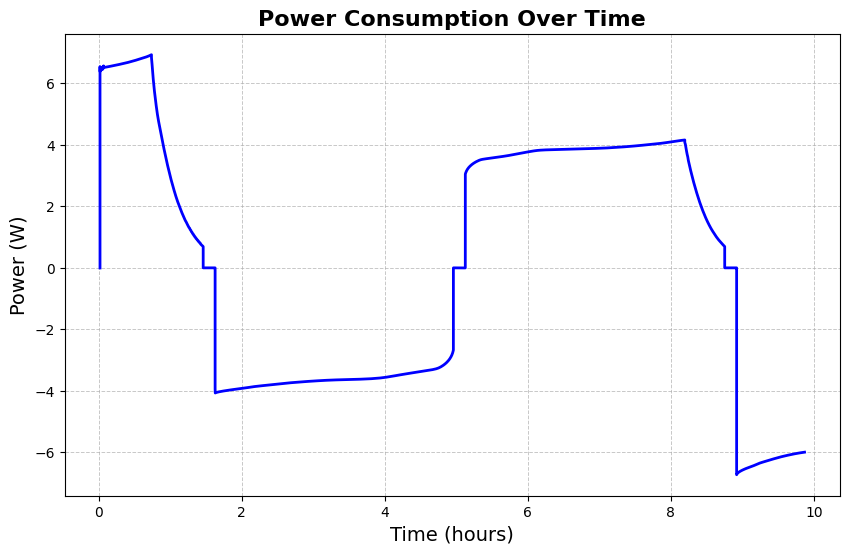

In [13]:
import matplotlib.pyplot as plt

# Improved Time Series Plot for Power Consumption Over Time
plt.figure(figsize=(10, 6))  # Adjust the figure size for better visibility
plt.plot(df['Time[h]'], df['Power[W]'], color='blue', linewidth=2)

# Add title and labels with improved styling
plt.title('Power Consumption Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Time (hours)', fontsize=14)
plt.ylabel('Power (W)', fontsize=14)

# Add grid for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

# Display the plot
plt.show()


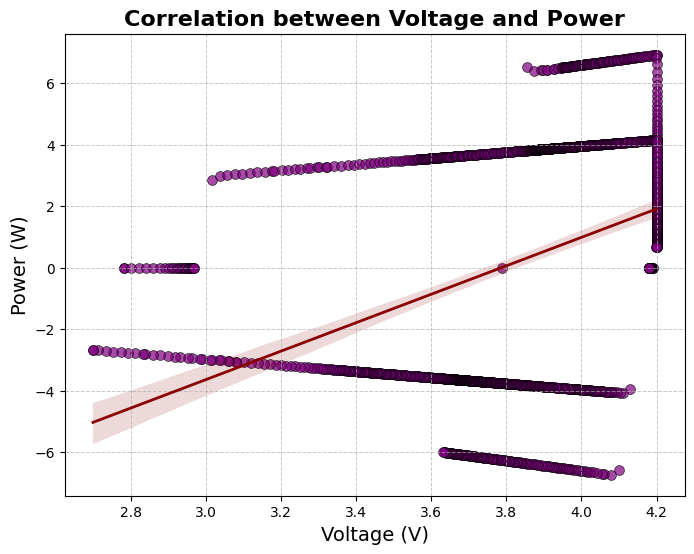

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size for better readability
plt.figure(figsize=(8, 6))

# Enhanced Scatterplot for Correlation between Voltage and Power
sns.scatterplot(
    x='U[V]',
    y='Power[W]',
    data=df,
    color='purple',  # Choose a distinctive color
    s=50,  # Adjust marker size
    alpha=0.7,  # Set transparency for better visualization of overlapping points
    edgecolor='black'  # Add edge color for better definition of points
)

# Add a regression line for better correlation understanding
sns.regplot(
    x='U[V]',
    y='Power[W]',
    data=df,
    scatter=False,
    color='darkred',
    line_kws={"linewidth": 2}
)

# Add title and labels with improved styling
plt.title('Correlation between Voltage and Power', fontsize=16, fontweight='bold')
plt.xlabel('Voltage (V)', fontsize=14)
plt.ylabel('Power (W)', fontsize=14)

# Add grid for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

# Display the plot
plt.show()

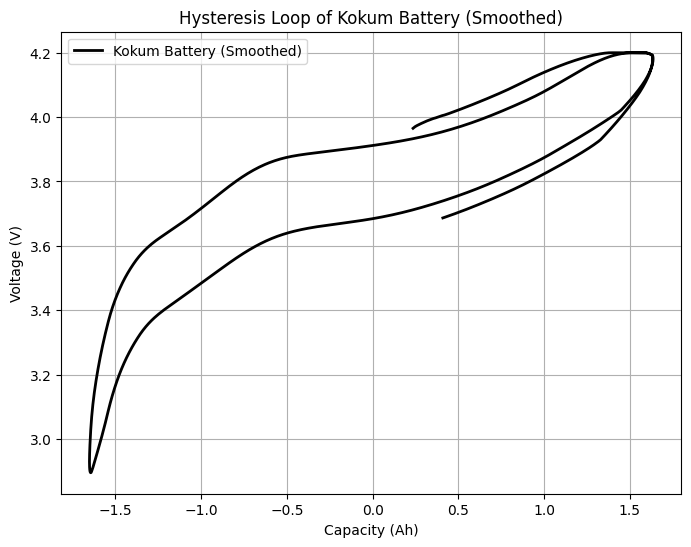

In [15]:
# Defining the variables
voltage = df['U[V]']
capacity = df['Ah[Ah]']

# Apply a rolling average to smooth the data (e.g., window size of 50)
voltage_smooth = voltage.rolling(window=50).mean()
capacity_smooth = capacity.rolling(window=50).mean()

# Plot the smoothed data
plt.figure(figsize=(8, 6))
plt.plot(capacity_smooth, voltage_smooth, label='Kokum Battery (Smoothed)', color='black', linewidth=2)

# Add labels and title
plt.xlabel('Capacity (Ah)')
plt.ylabel('Voltage (V)')
plt.title('Hysteresis Loop of Kokum Battery (Smoothed)')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

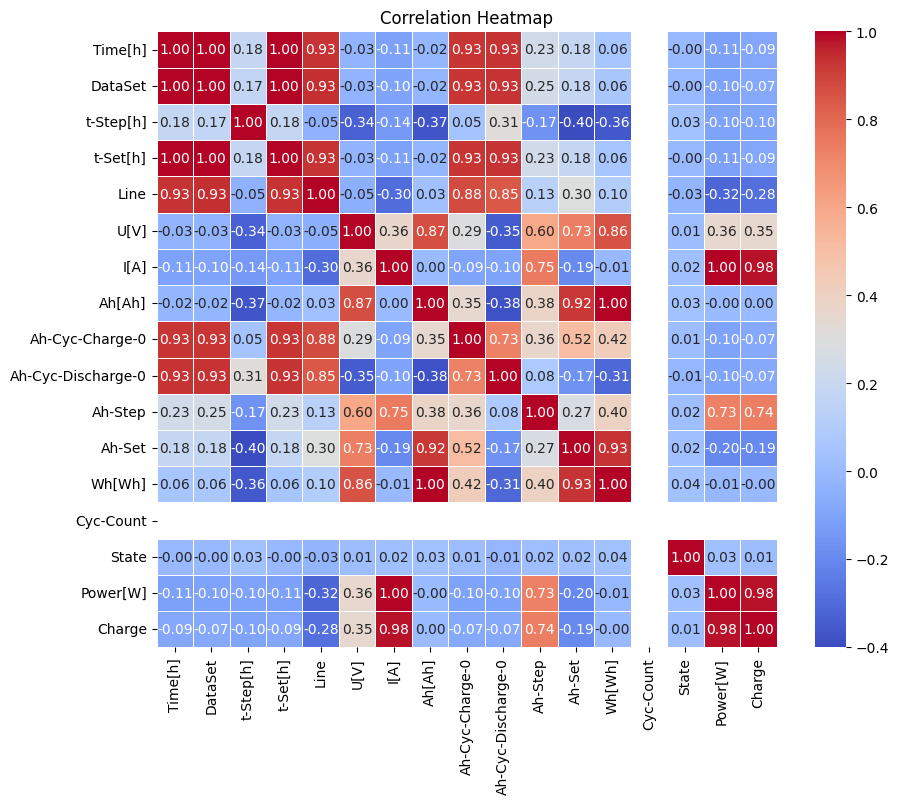

In [16]:
# Select only numeric columns before calculating correlation
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix on the numeric DataFrame
corr_df = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

## Calculation of Discharge and Charge Parameters with Charge Factor Determination

In [17]:
# Define times for discharge and charge periods
discharge_start_time = 1.62673160728387
discharge_end_time = 4.95922992715427
charge_start_time = 5.12598924189968
charge_end_time = 8.19596604340759
additional_charge_start_time = 8.20430040108116
additional_charge_end_time = 8.75430037617456

# Calculate durations
discharge_duration = discharge_end_time - discharge_start_time
charge_duration = charge_end_time - charge_start_time

# Filter data for discharge period and calculate average current and capacity
discharging_df = df[(df['Time[h]'] >= discharge_start_time) & (df['Time[h]'] <= discharge_end_time)]
average_discharge_current = discharging_df['I[A]'].mean()
discharge_capacity = -average_discharge_current * discharge_duration

# Filter data for charging period and calculate average charging current
charging_df = df[(df['Time[h]'] >= charge_start_time) &
                 (df['Time[h]'] <= charge_end_time) &
                 (df['Command'] == 'Charge')]
average_charging_current = charging_df['I[A]'].mean()

# Filter data for additional charge period and calculate total steady charge
additional_charge_df = df[(df['Time[h]'] >= additional_charge_start_time) &
                          (df['Time[h]'] <= additional_charge_end_time)]
total_steady_charge = additional_charge_df['Charge'].sum()

# Calculate total charge capacity
total_charge_capacity = total_steady_charge + (average_charging_current * charge_duration)

# Calculate charge factor
charge_factor = total_charge_capacity / discharge_capacity

# Output summary report
print("\n--- Summary Report ---")
print(f"Discharge Duration: {discharge_duration:.3f} hours")
print(f"Average Discharge Current: {average_discharge_current:.3f} A")
print(f"Discharge Capacity: {discharge_capacity:.3f} Ah")
print()
print(f"Charging Duration: {charge_duration:.3f} hours")
print(f"Average Charging Current: {average_charging_current:.3f} A")
print(f"Total Steady Charge: {total_steady_charge:.3f} Ah")
print(f"Total Charge Capacity: {total_charge_capacity:.3f} Ah")
print()
print(f"Charge Factor: {charge_factor:.3f}")



--- Summary Report ---
Discharge Duration: 3.332 hours
Average Discharge Current: -0.988 A
Discharge Capacity: 3.291 Ah

Charging Duration: 3.070 hours
Average Charging Current: 0.990 A
Total Steady Charge: 0.253 Ah
Total Charge Capacity: 3.292 Ah

Charge Factor: 1.000


In [18]:
def analyze_battery_data(df, discharge_start_time, discharge_end_time,
                         charge_start_time, charge_end_time,
                         additional_charge_start_time=None, additional_charge_end_time=None):
    # Calculate durations
    discharge_duration = discharge_end_time - discharge_start_time
    charge_duration = charge_end_time - charge_start_time

    # Filter data for discharge period and calculate average current and capacity
    discharging_df = df[(df['Time[h]'] >= discharge_start_time) & (df['Time[h]'] <= discharge_end_time)]
    average_discharge_current = discharging_df['I[A]'].mean()
    discharge_capacity = -average_discharge_current * discharge_duration

    # Filter data for charging period
    charging_df = df[(df['Time[h]'] >= charge_start_time) &
                     (df['Time[h]'] <= charge_end_time) &
                     (df['Command'] == 'Charge')]

    # Improve charge calculation by integrating current over time
    charge_duration_array = np.diff(charging_df['Time[h]'].values)  # Time intervals (h)
    current_array = charging_df['I[A]'].values[:-1]  # Current values (A), aligned with intervals
    charge_capacity = np.sum(current_array * charge_duration_array)  # Ah

    # Include additional charge period if provided
    if additional_charge_start_time and additional_charge_end_time:
        additional_charge_df = df[(df['Time[h]'] >= additional_charge_start_time) &
                                  (df['Time[h]'] <= additional_charge_end_time)]
        additional_charge_duration_array = np.diff(additional_charge_df['Time[h]'].values)  # Time intervals
        additional_current_array = additional_charge_df['I[A]'].values[:-1]  # Current values
        additional_charge = np.sum(additional_current_array * additional_charge_duration_array)  # Ah
        total_charge_capacity = charge_capacity + additional_charge
    else:
        total_charge_capacity = charge_capacity

    # Calculate charge factor
    charge_factor = total_charge_capacity / discharge_capacity

    # Output summary report
    summary_report = f"""
    --- Summary Report ---
    Discharge Duration: {discharge_duration:.3f} hours
    Average Discharge Current: {average_discharge_current:.3f} A
    Discharge Capacity: {discharge_capacity:.3f} Ah

    Charging Duration: {charge_duration:.3f} hours
    Integrated Charge Capacity: {charge_capacity:.3f} Ah
    """

    if additional_charge_start_time and additional_charge_end_time:
        summary_report += f"Additional Charge: {additional_charge:.3f} Ah\n"

    summary_report += f"Total Charge Capacity: {total_charge_capacity:.3f} Ah\n"
    summary_report += f"Charge Factor: {charge_factor:.3f}"

    return summary_report

In [19]:
print(analyze_battery_data(df, 1.62673160728387, 4.95922992715427, 5.12598924189968,
                       8.19596604340759, 8.20430040108116, 8.75430037617456))


    --- Summary Report ---
    Discharge Duration: 3.332 hours
    Average Discharge Current: -0.988 A
    Discharge Capacity: 3.291 Ah

    Charging Duration: 3.070 hours
    Integrated Charge Capacity: 3.039 Ah
    Additional Charge: 0.252 Ah
Total Charge Capacity: 3.291 Ah
Charge Factor: 1.000


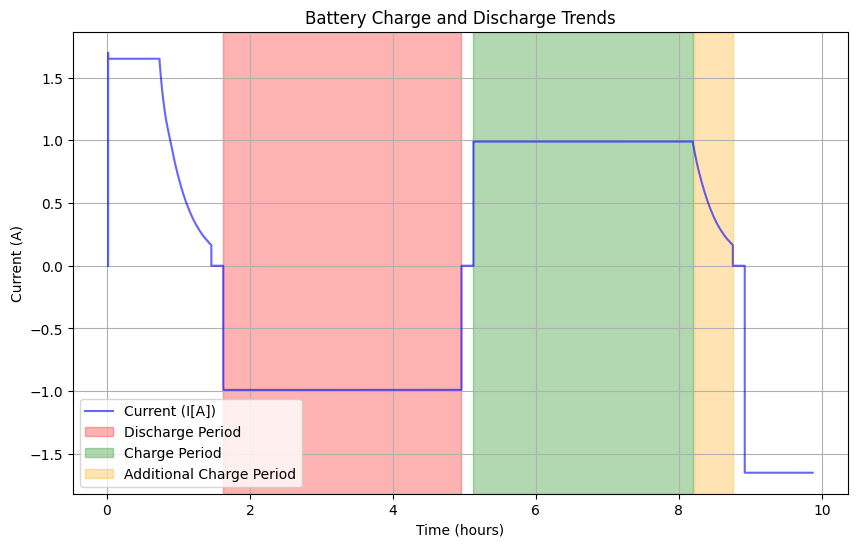

In [20]:
def visualize_charge_trends(df, discharge_start_time, discharge_end_time,
                            charge_start_time, charge_end_time,
                            additional_charge_start_time=None, additional_charge_end_time=None):
    # Ensure the DataFrame is not empty
    if df.empty or 'Time[h]' not in df.columns or 'I[A]' not in df.columns:
        print("Invalid or empty dataset.")
        return

    # Plot the entire time series for context
    plt.figure(figsize=(10, 6))
    plt.plot(df['Time[h]'], df['I[A]'], label='Current (I[A])', color='blue', alpha=0.6)
    plt.xlabel('Time (hours)')
    plt.ylabel('Current (A)')
    plt.title('Battery Charge and Discharge Trends')

    # Highlight the discharge period
    plt.axvspan(discharge_start_time, discharge_end_time, color='red', alpha=0.3, label='Discharge Period')

    # Highlight the charge period
    plt.axvspan(charge_start_time, charge_end_time, color='green', alpha=0.3, label='Charge Period')

    # Highlight the additional charge period if provided
    if additional_charge_start_time and additional_charge_end_time:
        plt.axvspan(additional_charge_start_time, additional_charge_end_time, color='orange', alpha=0.3, label='Additional Charge Period')

    plt.legend()
    plt.grid(True)
    plt.show()


visualize_charge_trends(df, 1.62673160728387, 4.95922992715427, 5.12598924189968,
                       8.19596604340759, 8.20430040108116, 8.75430037617456)
